# Toronto Menstrual Product Desert Zone Clustering

Identifies neighbourhood-level desert zones where residents lack walkable access to menstrual products, public washrooms, and community infrastructure. Uses weighted K-Means clustering on aggregated neighbourhood features, incorporating socioeconomic vulnerability from Statistics Canada Census 2021 & 2016.

**Data sources**: City of Toronto Open Data (parks, libraries, community centres, TTC routes), Statistics Canada Census 2021 & 2016 (income and population by neighbourhood).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
np.random.seed(42)

In [2]:
"""
## Step 1: Data Loading and Weight Assignment

Loads all location data and classifies rows as infrastructure (parks, libraries, community centres) or transit. Each infrastructure location receives a risk weight based on washroom and product availability:

| Washroom | Product | Weight | Interpretation |
|----------|---------|--------|----------------|
| Yes | Yes | 1 | Well served |
| No | Yes | 2 | Product present, no washroom |
| No | No | 3 | Desert (no product, no washroom) |
| Yes | No | 1 | Washroom present, lower risk |
"""
df = pd.read_csv("locations_all_with_neighborhoods.csv")

# Transit rows: Type in {0, 1, 3} with no washroom/product data → kept separate
transit_types = {"0", "1", "3"}
df["is_transit"] = df["Type"].astype(str).isin(transit_types)

# Infrastructure rows: Parks, Community Centres, Libraries, etc.
infra = df[~df["is_transit"]].copy()
transit = df[df["is_transit"]].copy()

print(f"Total rows:          {len(df):,}")
print(f"Infrastructure rows: {len(infra):,}")
print(f"Transit rows:        {len(transit):,} (excluded from main clustering)")

# assign weights to infrastructure rows based on washroom/product availability
def assign_weight(row):
    """
    Weight logic (lower = better served):
      washroom=1, product=1 → 1
      washroom=0, product=1 → 2
      washroom=0, product=0 → 3  ← desert signal
      washroom=1, product=0 → 1  (washroom present, low risk)
    NaN washroom treated as 0 (unknown = absent assumption, conservative).
    """
    w = 0 if pd.isna(row["Washroom"]) else int(row["Washroom"])
    p = int(row["Product"])
    if w == 1 and p == 1:
        return 1
    elif w == 0 and p == 1:
        return 2
    else:  # w=0, p=0 or w=1, p=0
        return 3 if p == 0 else 1

infra["weight"] = infra.apply(assign_weight, axis=1)

print("\nWeight distribution:")
print(infra["weight"].value_counts().sort_index())


Total rows:          18,790
Infrastructure rows: 1,794
Transit rows:        16,996 (excluded from main clustering)

Weight distribution:
weight
1      83
2       1
3    1710
Name: count, dtype: int64


## Step 2: Neighbourhood-Level Feature Aggregation

Aggregates individual location data to the neighbourhood level. Features computed per neighbourhood:

| Feature | Description |
|---------|-------------|
| `avg_weight` | Mean risk weight across all locations (higher = more at risk) |
| `pct_no_washroom` | Share of locations missing a washroom |
| `pct_no_product` | Share of locations missing menstrual products |
| `pct_desert` | Share of fully unserved locations (weight = 3) |
| `dist_to_product_km` | Distance from neighbourhood centroid to nearest product location (km) |
| `transit_per_loc` | Transit stop count normalised by number of infrastructure locations |
| `pct_within_1500m` | Fraction of infrastructure locations with a product accessible within 1500m on foot |

In [3]:
# Drop rows with no neighbourhood assignment
infra_nb = infra.dropna(subset=["neighbourhood_name"]).copy()

def neighbourhood_features(group):
    """Compute per-neighbourhood desert features."""
    n = len(group)
    
    # Weighted risk score: average weight (higher = more at risk)
    avg_weight = group["weight"].mean()
    
    # % of locations with zero washroom
    pct_no_washroom = (group["Washroom"].fillna(0) == 0).mean()
    
    # % of locations with zero product
    pct_no_product = (group["Product"] == 0).mean()
    
    # Count of "fully desert" locations (weight=3)
    n_desert = (group["weight"] == 3).sum()
    pct_desert = n_desert / n
    
    # Centroid
    lat = group["Latitude"].mean()
    lon = group["Longitude"].mean()
    
    return pd.Series({
        "n_locations": n,
        "avg_weight": avg_weight,
        "pct_no_washroom": pct_no_washroom,
        "pct_no_product": pct_no_product,
        "pct_desert": pct_desert,
        "n_desert": n_desert,
        "centroid_lat": lat,
        "centroid_lon": lon,
    })

nb_feats = infra_nb.groupby("neighbourhood_name").apply(neighbourhood_features).reset_index()

# Transit accessibility per neighbourhood
# Count transit stops per neighbourhood; low count = low accessibility
transit_nb = transit.dropna(subset=["neighbourhood_name"])
transit_counts = transit_nb.groupby("neighbourhood_name").size().rename("n_transit")
nb_feats = nb_feats.merge(transit_counts, on="neighbourhood_name", how="left")
nb_feats["n_transit"] = nb_feats["n_transit"].fillna(0)

# Normalise transit by location count (stops per infra location)
nb_feats["transit_per_loc"] = nb_feats["n_transit"] / nb_feats["n_locations"].clip(lower=1)

# Distance to nearest product location (global, not just in neighbourhood)
product_locs = infra[infra["Product"] == 1][["Latitude", "Longitude"]].dropna().values

def min_dist_to_product(row):
    if len(product_locs) == 0:
        return np.nan
    pt = np.array([[row["centroid_lat"], row["centroid_lon"]]])
    dists = cdist(pt, product_locs, metric="euclidean")
    # Convert to rough km (1 degree lat ≈ 111 km in Toronto)
    return dists.min() * 111

nb_feats["dist_to_product_km"] = nb_feats.apply(min_dist_to_product, axis=1)

# Walkability: % of infra locations within 1500m of a product
# For each individual infra location in the neighbourhood, check if the nearest
# product is reachable within a 1500m walk. Aggregated to neighbourhood level
WALK_KM = 1.5

def pct_within_walk(group):
    pts = group[["Latitude", "Longitude"]].dropna().values
    if len(pts) == 0 or len(product_locs) == 0:
        return 0.0
    dists = cdist(pts, product_locs, metric="euclidean") * 111  # degrees → km
    return float((dists.min(axis=1) <= WALK_KM).mean())

walk_coverage = (
    infra_nb.groupby("neighbourhood_name")
    .apply(pct_within_walk)
    .rename("pct_within_1500m")
    .reset_index()
)
nb_feats = nb_feats.merge(walk_coverage, on="neighbourhood_name", how="left")
nb_feats["pct_within_1500m"] = nb_feats["pct_within_1500m"].fillna(0)

print(f"\nNeighbourhoods with features: {len(nb_feats)}")
print(nb_feats.describe().round(3))
print(f"\n1500m walkability coverage (fraction of infra locations with product within walk):")
print(nb_feats["pct_within_1500m"].describe().round(3))


Neighbourhoods with features: 158
       n_locations  avg_weight  pct_no_washroom  pct_no_product  pct_desert  \
count      158.000     158.000          158.000         158.000     158.000   
mean        11.354       2.901            0.776           0.950       0.950   
std          5.845       0.137            0.152           0.069       0.069   
min          2.000       2.000            0.200           0.500       0.500   
25%          7.000       2.837            0.692           0.918       0.918   
50%         10.000       3.000            0.800           1.000       1.000   
75%         14.000       3.000            0.875           1.000       1.000   
max         36.000       3.000            1.000           1.000       1.000   

       n_desert  centroid_lat  centroid_lon  n_transit  transit_per_loc  \
count   158.000       158.000       158.000    158.000          158.000   
mean     10.823        43.709       -79.397    104.000           10.025   
std       5.609         0.05

## Step 3: Socioeconomic Feature Merge

Merges three five-year average columns (2015-2020) from Statistics Canada Census 2021. Using multi-year averages improves temporal stability compared to a single census year snapshot.

| Feature | Description |
|---------|-------------|
| `lim_at_pct` | Low-Income Measure after-tax prevalence (LIM-AT%), captures economic vulnerability |
| `avg_immigrant_pop` | Average immigrant population, a compound vulnerability indicator |
| `avg_pop_1054` | Average working-age population (10 to 54 yrs), represents exposure scale |

Population columns are log-transformed before entering the model to reduce right skew.

In [4]:
# Using 2015-2020 averages for stability across census years
AVG_POP_COL = "2015-2020 Avg 10-54 yrs Pop."
AVG_IMM_COL = "2015-2020 Avg Immigrant Pop."
AVG_LIM_COL = "2015-2020 Avg LIM-AT%"

income_raw = pd.read_csv("OKAI-period/clean data/income_data_neighborhoods.csv")
socio = income_raw[["Neighbourhood Name", AVG_POP_COL, AVG_IMM_COL, AVG_LIM_COL]].copy()
socio.columns = ["neighbourhood_name", "avg_pop_1054", "avg_immigrant_pop", "lim_at_pct"]

def clean_num(s):
    return pd.to_numeric(s.astype(str).str.replace(",", ""), errors="coerce")

socio["avg_pop_1054"]      = clean_num(socio["avg_pop_1054"])
socio["avg_immigrant_pop"] = clean_num(socio["avg_immigrant_pop"])
socio["lim_at_pct"]        = clean_num(socio["lim_at_pct"])

nb_feats = nb_feats.merge(socio, on="neighbourhood_name", how="left")

# Log-scale population to reduce right skew
nb_feats["log_pop_1054"]      = np.log1p(nb_feats["avg_pop_1054"])
nb_feats["log_immigrant_pop"] = np.log1p(nb_feats["avg_immigrant_pop"])

matched = nb_feats["lim_at_pct"].notna().sum()
print(f"Socioeconomic join: {matched}/{len(nb_feats)} neighbourhoods matched ({matched/len(nb_feats)*100:.1f}%)")
print(nb_feats[["neighbourhood_name", "lim_at_pct", "avg_pop_1054", "avg_immigrant_pop"]].describe().round(2))

Socioeconomic join: 158/158 neighbourhoods matched (100.0%)
       lim_at_pct  avg_pop_1054  avg_immigrant_pop
count      158.00        158.00             158.00
mean        16.32      15526.84           17256.40
std          6.04       5667.72            5991.24
min          4.40       6065.00            6313.00
25%         12.26      11115.00           12312.00
50%         15.42      14472.50           16522.50
75%         19.65      19463.12           21698.75
max         34.85      32675.00           33095.00


## Step 4: Feature Matrix and Continuous Weighting

Ten features are assembled and standardised (zero mean, unit variance). Two adjustments are applied before standardisation:

1. **Transit dampening**: `transit_per_loc` is multiplied by 0.5, reducing its influence relative to walkability and infrastructure features. Transit stop count reflects commute access rather than walkable proximity.
2. **Direction alignment**: `transit_per_loc` and `pct_within_1500m` are negated so that a high value consistently means "more at risk" across all features.

**Continuous sample weights** are computed per neighbourhood as a normalised blend of LIM-AT% (50%), immigrant population (30%), and working-age population (20%), plus a 0.1 baseline. These are passed to KMeans via `sample_weight` so that socioeconomically vulnerable neighbourhoods exert greater influence on centroid placement.

In [5]:
# Feature matrix for clustering
feature_cols = [
    "avg_weight",          # core desert risk (higher = worse)
    "pct_no_washroom",     # lack of washrooms
    "pct_no_product",      # lack of products
    "pct_desert",          # % fully unserved locations
    "dist_to_product_km",  # spatial isolation from products
    "transit_per_loc",     # transit density — dampened (see below)
    "pct_within_1500m",    # walkability: fraction of infra within 1500m of a product
    "lim_at_pct",          # low-income prevalence (socioeconomic vulnerability)
    "log_pop_1054",        # working-age population (exposure scale)
    "log_immigrant_pop",   # immigrant population (compound vulnerability)
]

X_raw = nb_feats[feature_cols].copy()
X_raw = X_raw.fillna(X_raw.median())

# Transit is a secondary signal (commute time ≠ walkable access), dampen its
# variance contribution by halving it before standardisation so it influences
# cluster geometry less than the walkability and infrastructure features
X_raw["transit_per_loc"] = X_raw["transit_per_loc"] * 0.5

# Invert directional features so HIGH value = more at risk (desert-like)
X_raw["transit_per_loc"]   = -X_raw["transit_per_loc"]
X_raw["pct_within_1500m"]  = -X_raw["pct_within_1500m"]
X_raw = X_raw.rename(columns={
    "transit_per_loc":  "transit_isolation",
    "pct_within_1500m": "walkability_gap",
})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Continuous socioeconomic sample weights
# Each neighbourhood gets a continuous weight ∈ (0.1, 1.1] representing its
# vulnerability. High LIM-AT%, large immigrant pop, and large working-age pop
# all increase the weight, so KMeans centroids are pulled toward at-risk areas
def minmax_norm(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else pd.Series(np.zeros(len(s)), index=s.index)

lim_norm = minmax_norm(nb_feats["lim_at_pct"].fillna(nb_feats["lim_at_pct"].median()))
imm_norm = minmax_norm(nb_feats["avg_immigrant_pop"].fillna(0))
pop_norm = minmax_norm(nb_feats["avg_pop_1054"].fillna(0))

nb_feats["socio_weight"] = (lim_norm * 0.5 + imm_norm * 0.3 + pop_norm * 0.2) + 0.1

print("Continuous weight distribution:")
print(nb_feats["socio_weight"].describe().round(4))
print(f"\nTop 5 highest-weighted neighbourhoods:")
print(nb_feats.nlargest(5, "socio_weight")[["neighbourhood_name", "lim_at_pct", "avg_immigrant_pop", "avg_pop_1054", "socio_weight"]])

Continuous weight distribution:
count    158.0000
mean       0.4895
std        0.1599
min        0.1406
25%        0.3643
50%        0.4630
75%        0.6266
max        0.8638
Name: socio_weight, dtype: float64

Top 5 highest-weighted neighbourhoods:
                    neighbourhood_name  lim_at_pct  avg_immigrant_pop  \
95   Mount Olive-Silverstone-Jamestown       21.75            32088.0   
133                   Thorncliffe Park       34.85            20618.0   
53              Glenfield-Jane Heights       20.30            30120.0   
93                           Moss Park       27.60            19975.0   
49                     Flemingdon Park       27.30            22225.0   

     avg_pop_1054  socio_weight  
95        31370.0      0.863805  
133       19470.0      0.860990  
53        27890.0      0.791795  
93        24245.0      0.770628  
49        21400.0      0.769523  


## Step 5: Cluster Count Selection

Computes three cluster quality metrics for k = 2 through 10:

- **Inertia (elbow method)**: total within-cluster sum of squares
- **Silhouette score**: measures how well-separated and cohesive clusters are (higher is better)
- **Davies-Bouldin score**: ratio of intra-cluster scatter to inter-cluster distance (lower is better)

k = 4 is chosen where the silhouette score plateaus and the four groups correspond to interpretable service tiers: Desert Zone, Low Service, Moderate Service, and Well Served.

In [6]:
# KMeans clustering and evaluation
k_range = range(2, 11)
inertias, silhouettes, davies, calinski = [], [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    davies.append(davies_bouldin_score(X_scaled, labels))
    calinski.append(calinski_harabasz_score(X_scaled, labels))


## Step 6: Fit Final K-Means Model

Fits K-Means with k = 4 and `n_init = 30` (30 random initialisations, best inertia kept). Clusters are re-ordered so that cluster 0 is always the most at-risk group (highest average weight).

The continuous socioeconomic sample weights from Step 4 are passed here, so that neighbourhoods with high LIM-AT%, large immigrant population, and large working-age population pull centroids more strongly than lower-risk areas.

In [7]:
K_FINAL = 4
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=30)
nb_feats["cluster"] = km_final.fit_predict(X_scaled, sample_weight=nb_feats["socio_weight"].values)

cluster_rank = nb_feats.groupby("cluster")["avg_weight"].mean().sort_values(ascending=False)
rank_map = {old: new for new, old in enumerate(cluster_rank.index)}
nb_feats["cluster"] = nb_feats["cluster"].map(rank_map)

cluster_labels = {
    0: "Desert Zone (most at risk)",
    1: "Low Service",
    2: "Moderate Service",
    3: "Well Served",
}
nb_feats["cluster_label"] = nb_feats["cluster"].map(cluster_labels)

COLORS = {
    0: "#d32f2f",
    1: "#f57c00",
    2: "#fbc02d",
    3: "#388e3c",
}

print("Cluster Summary:")
summary_cols = feature_cols + ["socio_weight"]
summary = nb_feats.groupby("cluster_label")[summary_cols].mean().round(3)
summary["transit_per_loc"] = -summary["transit_per_loc"]
print(summary)

print("\nSocioeconomic Profile by Cluster:")
print(nb_feats.groupby("cluster_label")[
    ["lim_at_pct", "avg_immigrant_pop", "avg_pop_1054", "socio_weight"]
].mean().round(2))

print("\nValidation Metrics (k=4, continuous weights):")
final_labels = nb_feats["cluster"].values
print(f"  Silhouette Score:         {silhouette_score(X_scaled, final_labels):.4f}  (>0.3 acceptable, >0.5 good)")
print(f"  Davies-Bouldin Score:     {davies_bouldin_score(X_scaled, final_labels):.4f}  (lower is better)")
print(f"  Calinski-Harabasz Score:  {calinski_harabasz_score(X_scaled, final_labels):.1f}  (higher is better)")

Cluster Summary:
                            avg_weight  pct_no_washroom  pct_no_product  \
cluster_label                                                             
Desert Zone (most at risk)       2.993            0.819           0.997   
Low Service                      2.989            0.845           0.995   
Moderate Service                 2.859            0.762           0.929   
Well Served                      2.681            0.607           0.841   

                            pct_desert  dist_to_product_km  transit_per_loc  \
cluster_label                                                                 
Desert Zone (most at risk)       0.997               2.092          -13.779   
Low Service                      0.995               1.093           -7.803   
Moderate Service                 0.929               0.761           -8.087   
Well Served                      0.841               0.468          -13.042   

                            pct_within_1500m  lim_at_pct 

## Step 6b: Continuous Output Risk Score

Each neighbourhood receives a composite risk score from 0 to 1 that blends infrastructure gaps with socioeconomic vulnerability. This supports ranked prioritisation within and across clusters.

| Component | Weight | Feature |
|-----------|--------|---------|
| Infrastructure gap | 30% | `avg_weight` |
| Spatial isolation | 20% | `dist_to_product_km` |
| Unserved location share | 20% | `pct_desert` |
| Low-income prevalence | 20% | `lim_at_pct` |
| Immigrant population | 10% | `avg_immigrant_pop` |

In [8]:
# Composite risk score per neighbourhood (0–1), higher = more at risk
nb_feats["risk_score"] = (
    minmax_norm(nb_feats["avg_weight"])                                          * 0.30 +
    minmax_norm(nb_feats["dist_to_product_km"])                                  * 0.20 +
    minmax_norm(nb_feats["pct_desert"])                                          * 0.20 +
    minmax_norm(nb_feats["lim_at_pct"].fillna(nb_feats["lim_at_pct"].median())) * 0.20 +
    minmax_norm(nb_feats["avg_immigrant_pop"].fillna(0))                         * 0.10
)

print("Risk Score Distribution:")
print(nb_feats["risk_score"].describe().round(4))

print("\nTop 10 Highest-Risk Neighbourhoods:")
top10 = nb_feats.nlargest(10, "risk_score")[
    ["neighbourhood_name", "cluster_label", "risk_score",
     "lim_at_pct", "avg_immigrant_pop", "dist_to_product_km"]
]
print(top10.to_string(index=False))

print("\nAverage Risk Score by Cluster:")
print(nb_feats.groupby("cluster_label")["risk_score"].mean().sort_values(ascending=False).round(4))

Risk Score Distribution:
count    158.0000
mean       0.6164
std        0.1035
min        0.1359
25%        0.5641
50%        0.6221
75%        0.6881
max        0.8450
Name: risk_score, dtype: float64

Top 10 Highest-Risk Neighbourhoods:
 neighbourhood_name              cluster_label  risk_score  lim_at_pct  avg_immigrant_pop  dist_to_product_km
Westminster-Branson Desert Zone (most at risk)    0.845023       19.05            25910.0            4.038382
     Bathurst Manor Desert Zone (most at risk)    0.799660       14.20            15765.0            4.593170
    Flemingdon Park Desert Zone (most at risk)    0.797504       27.30            22225.0            2.036492
   Newtonbrook West Desert Zone (most at risk)    0.778402       20.80            23715.0            2.446847
           Oakridge                Low Service    0.775478       32.55            13653.0            1.478756
       Woburn North Desert Zone (most at risk)    0.772299       21.35            26684.5            

## Step 7: Bootstrap Stability Check

Validates that the k = 4 cluster structure is stable across random subsamples. Runs 100 iterations, each fitting K-Means on a randomly drawn 80% subsample and computing the silhouette score. A narrow 95% confidence interval confirms the cluster structure is not an artefact of any particular data subset.

In [9]:
# Bootstrap stability check: run KMeans on 100 random 80% subsamples and check silhouette score distribution
print("\nBootstrap Stability (100 iterations, 80% subsample)")
n_boot = 100
sil_boot = []
for _ in range(n_boot):
    idx = np.random.choice(len(X_scaled), size=int(0.8 * len(X_scaled)), replace=False)
    X_sub = X_scaled[idx]
    km_b = KMeans(n_clusters=K_FINAL, random_state=None, n_init=10)
    lbl_b = km_b.fit_predict(X_sub)
    if len(np.unique(lbl_b)) > 1:
        sil_boot.append(silhouette_score(X_sub, lbl_b))

sil_boot = np.array(sil_boot)
print(f"  Silhouette mean ± std:  {sil_boot.mean():.4f} ± {sil_boot.std():.4f}")
print(f"  95th pctile range:      [{np.percentile(sil_boot,2.5):.4f}, {np.percentile(sil_boot,97.5):.4f}]")


Bootstrap Stability (100 iterations, 80% subsample)
  Silhouette mean ± std:  0.2249 ± 0.0099
  95th pctile range:      [0.2046, 0.2426]


## Step 8: Visualization

The following figures characterise cluster quality, separation in reduced feature space, feature profiles by cluster, and the spatial distribution of desert zones across Toronto:

- **Figure A**: Elbow method (inertia vs k)
- **Figure B**: Silhouette score vs k
- **Figure C**: Davies-Bouldin score vs k
- **Figure D**: Bootstrap silhouette stability distribution
- **Figure E**: PCA 2D projection of cluster assignments
- **Figure F**: Normalised feature means by cluster
- **Figure G**: Spatial map of desert zones across Toronto neighbourhoods

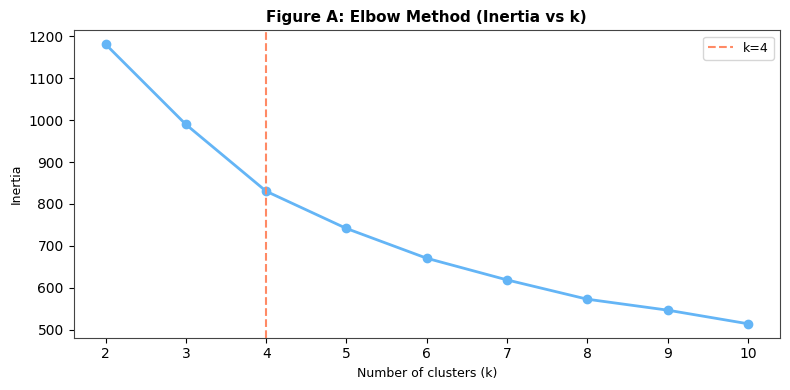

In [10]:
# Figure A: Elbow Method
fig, ax = plt.subplots(figsize=(8, 4), facecolor="#FFFFFF")
ax.plot(list(k_range), inertias, "o-", color="#64b5f6", lw=2)
ax.axvline(K_FINAL, color="#ff8a65", ls="--", lw=1.5, label=f"k={K_FINAL}")
ax.set_facecolor("#ffffff")
ax.tick_params(colors="black")
ax.spines[:].set_color("#444")
ax.set_title("Figure A: Elbow Method (Inertia vs k)", color="black", fontsize=11, fontweight="bold")
ax.set_xlabel("Number of clusters (k)", color="black", fontsize=9)
ax.set_ylabel("Inertia", color="black", fontsize=9)
ax.legend(labelcolor="black", fontsize=9)
fig.tight_layout()
plt.show()

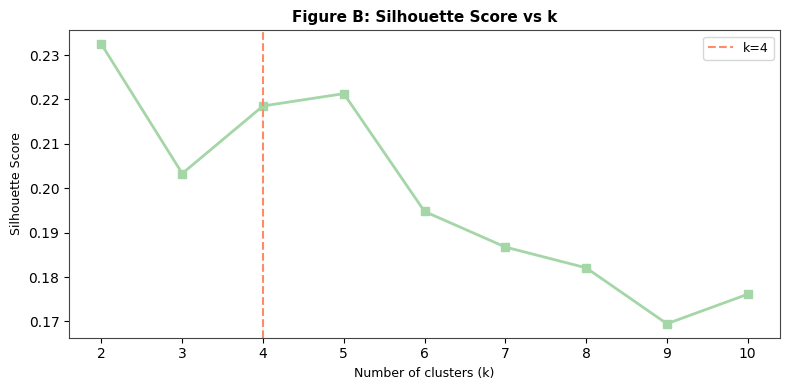

In [11]:
# Figure B: Silhouette Score
fig, ax = plt.subplots(figsize=(8, 4), facecolor="#FFFFFF")
ax.plot(list(k_range), silhouettes, "s-", color="#a5d6a7", lw=2)
ax.axvline(K_FINAL, color="#ff8a65", ls="--", lw=1.5, label=f"k={K_FINAL}")
ax.set_facecolor("#ffffff")
ax.tick_params(colors="black")
ax.spines[:].set_color("#444")
ax.set_title("Figure B: Silhouette Score vs k", color="black", fontsize=11, fontweight="bold")
ax.set_xlabel("Number of clusters (k)", color="black", fontsize=9)
ax.set_ylabel("Silhouette Score", color="black", fontsize=9)
ax.legend(labelcolor="black", fontsize=9)
fig.tight_layout()
plt.show()

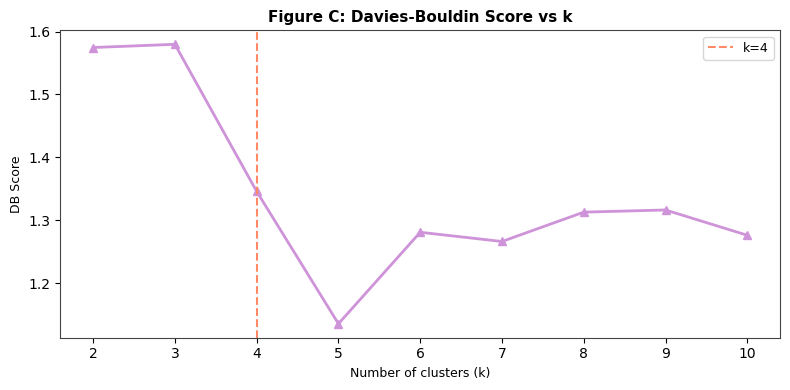

In [12]:
# Figure C: Davies-Bouldin Score
fig, ax = plt.subplots(figsize=(8, 4), facecolor="#ffffff")
ax.plot(list(k_range), davies, "^-", color="#ce93d8", lw=2)
ax.axvline(K_FINAL, color="#ff8a65", ls="--", lw=1.5, label=f"k={K_FINAL}")
ax.set_facecolor("#ffffff")
ax.tick_params(colors="black")
ax.spines[:].set_color("#444")
ax.set_title("Figure C: Davies-Bouldin Score vs k", color="black", fontsize=11, fontweight="bold")
ax.set_xlabel("Number of clusters (k)", color="black", fontsize=9)
ax.set_ylabel("DB Score", color="black", fontsize=9)
ax.legend(labelcolor="black", fontsize=9)
fig.tight_layout()
plt.show()

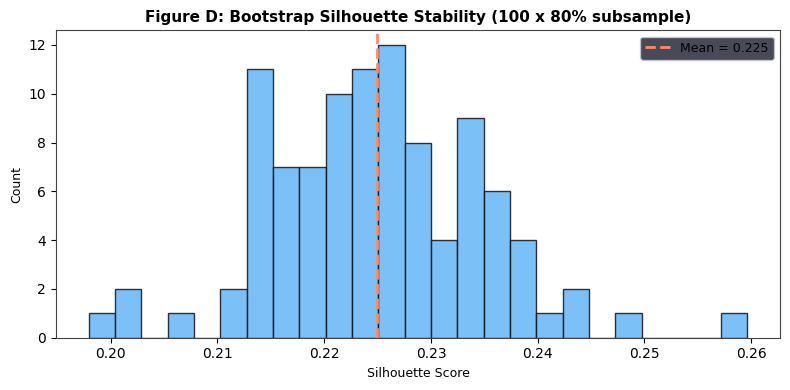

In [13]:
# Figure D: Bootstrap Silhouette Stability
fig, ax = plt.subplots(figsize=(8, 4), facecolor="#ffffff")
ax.hist(sil_boot, bins=25, color="#64b5f6", edgecolor="#0f1117", alpha=0.85)
ax.axvline(sil_boot.mean(), color="#ff8a65", ls="--", lw=2, label=f"Mean = {sil_boot.mean():.3f}")
ax.set_facecolor("#ffffff")
ax.tick_params(colors="black")
ax.spines[:].set_color("#444")
ax.set_title("Figure D: Bootstrap Silhouette Stability (100 x 80% subsample)", color="black", fontsize=11, fontweight="bold")
ax.set_xlabel("Silhouette Score", color="black", fontsize=9)
ax.set_ylabel("Count", color="black", fontsize=9)
ax.legend(facecolor="#1a1d2e", labelcolor="black", fontsize=9)
fig.tight_layout()
plt.show()

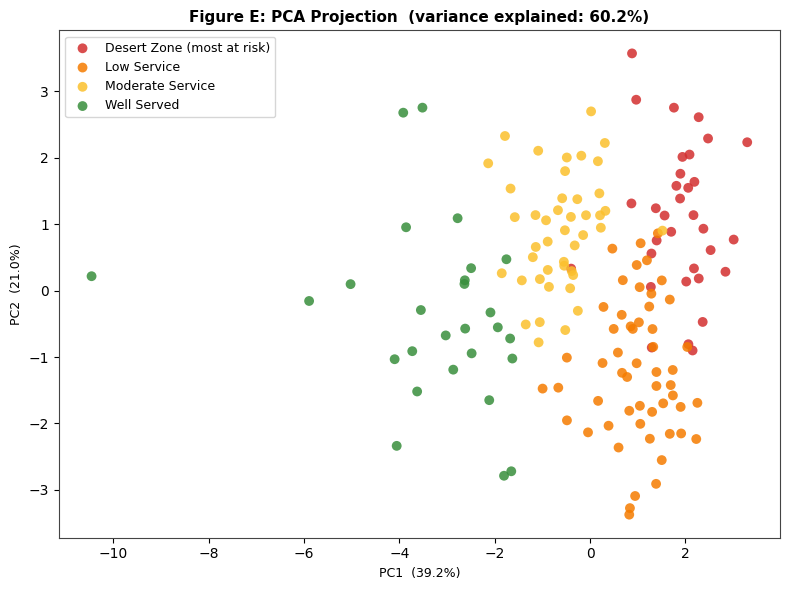

In [14]:
# Figure E: PCA 2D Cluster Projection
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6), facecolor="#ffffff")
for c, lbl in cluster_labels.items():
    mask = nb_feats["cluster"] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=COLORS[c], label=lbl, s=50, alpha=0.85, edgecolors="none")
ax.set_facecolor("#ffffff")
ax.tick_params(colors="black")
ax.spines[:].set_color("#444")
ax.set_title(
    f"Figure E: PCA Projection  (variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%)",
    color="black", fontsize=11, fontweight="bold"
)
ax.set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0]*100:.1f}%)", color="black", fontsize=9)
ax.set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1]*100:.1f}%)", color="black", fontsize=9)
ax.legend(labelcolor="black", fontsize=9)
fig.tight_layout()
plt.show()

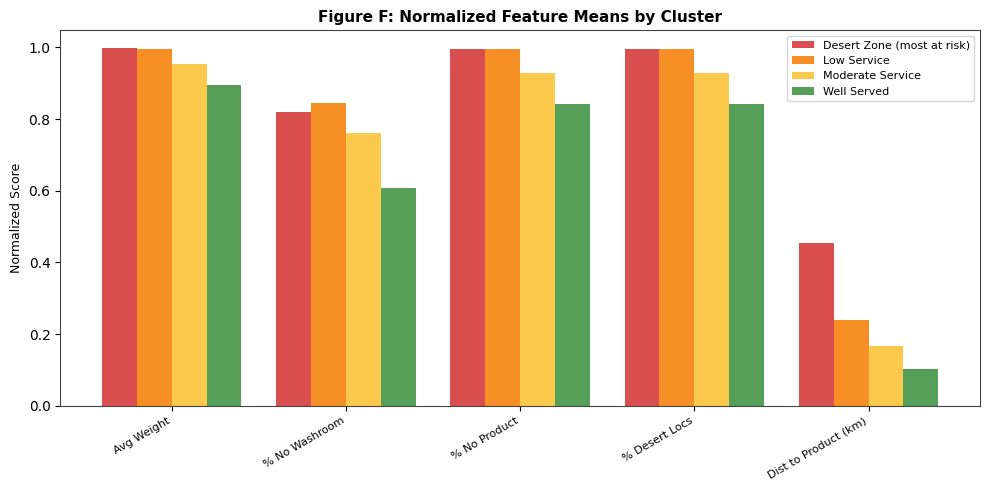

In [15]:
# Figure F: Normalized Feature Means by Cluster
display_feats = ["avg_weight", "pct_no_washroom", "pct_no_product", "pct_desert", "dist_to_product_km"]
feat_labels   = ["Avg Weight", "% No Washroom", "% No Product", "% Desert Locs", "Dist to Product (km)"]
x     = np.arange(len(display_feats))
bar_w = 0.2

fig, ax = plt.subplots(figsize=(10, 5), facecolor="#ffffff")
for i, (c, lbl) in enumerate(cluster_labels.items()):
    mask  = nb_feats["cluster"] == c
    vals  = nb_feats.loc[mask, display_feats].mean().values
    max_v = nb_feats[display_feats].max().values.clip(min=1e-9)
    ax.bar(x + i * bar_w, vals / max_v, bar_w, color=COLORS[c], label=lbl, alpha=0.85)
ax.set_facecolor("#ffffff")
ax.tick_params(colors="black")
ax.spines[:].set_color("#444")
ax.set_xticks(x + bar_w * 1.5)
ax.set_xticklabels(feat_labels, rotation=30, ha="right", fontsize=8, color="black")
ax.set_title("Figure F: Normalized Feature Means by Cluster", color="black", fontsize=11, fontweight="bold")
ax.set_ylabel("Normalized Score", color="black", fontsize=9)
ax.legend(labelcolor="black", fontsize=8)
fig.tight_layout()
plt.show()

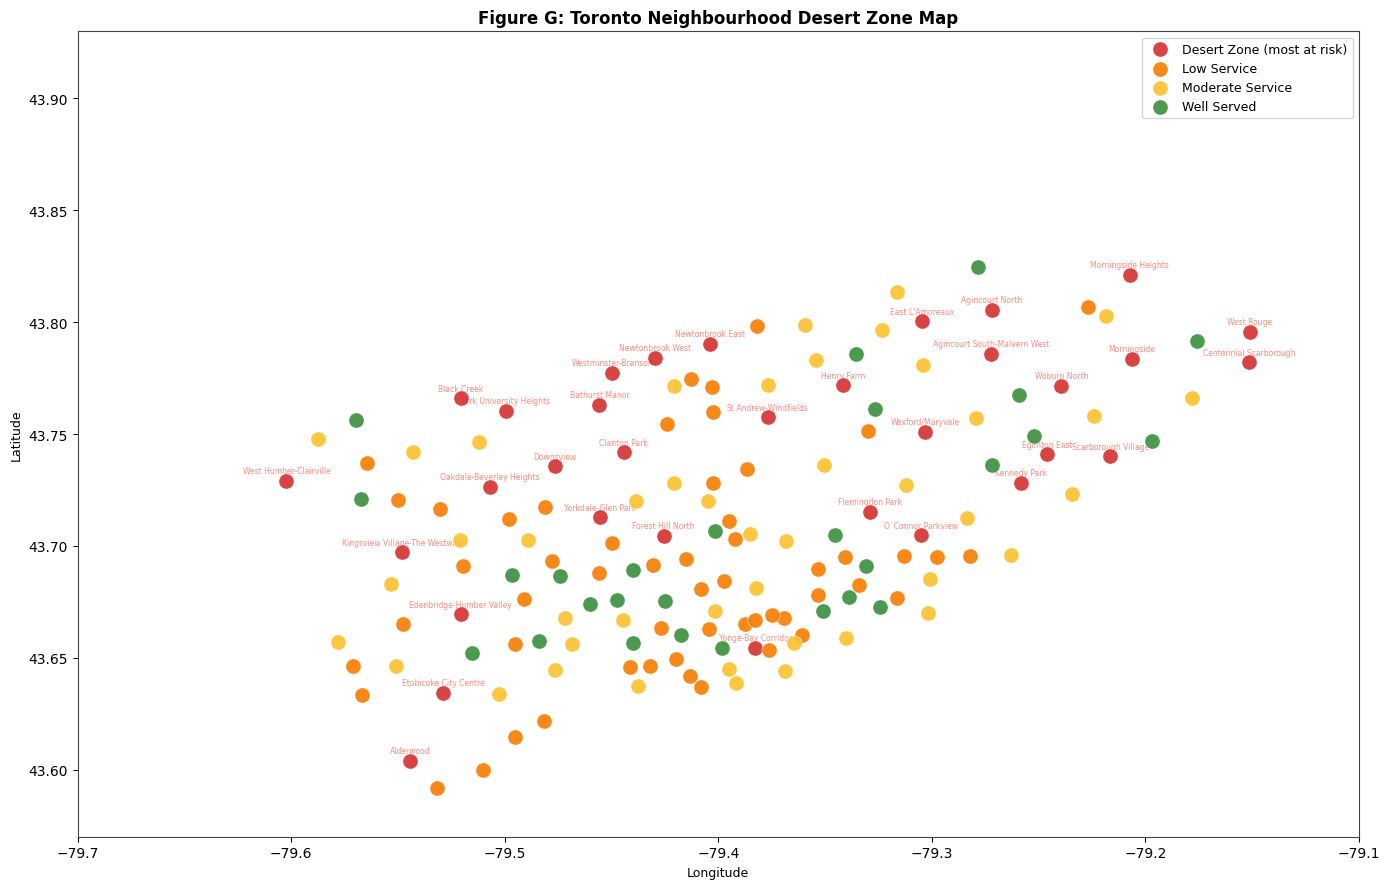

Figure saved: desert_zone_clusters.png


In [16]:
# Figure G: Toronto Neighbourhood Desert Zone Map
fig, ax = plt.subplots(figsize=(14, 9), facecolor="#ffffff")

for c, lbl in cluster_labels.items():
    mask = nb_feats["cluster"] == c
    ax.scatter(
        nb_feats.loc[mask, "centroid_lon"],
        nb_feats.loc[mask, "centroid_lat"],
        c=COLORS[c], s=120, label=lbl, alpha=0.9, zorder=5,
        edgecolors="white", linewidths=0.4
    )
    if c == 0:
        for _, row in nb_feats[mask].iterrows():
            ax.annotate(
                row["neighbourhood_name"],
                (row["centroid_lon"], row["centroid_lat"]),
                fontsize=5.5, color="#ff8a80", ha="center", va="bottom",
                xytext=(0, 4), textcoords="offset points"
            )

ax.set_facecolor("#ffffff")
ax.tick_params(colors="black")
ax.spines[:].set_color("#444")
ax.set_title(
    "Figure G: Toronto Neighbourhood Desert Zone Map",
    color="black", fontsize=12, fontweight="bold"
)
ax.set_xlabel("Longitude", color="black", fontsize=9)
ax.set_ylabel("Latitude", color="black", fontsize=9)
ax.legend(labelcolor="black", fontsize=9, loc="upper right")
ax.set_xlim(-79.70, -79.10)
ax.set_ylim(43.57, 43.93)

plt.savefig("desert_zone_clusters.png", dpi=160, bbox_inches="tight", facecolor="#ffffff")
fig.tight_layout()
plt.show()
print("Figure saved: desert_zone_clusters.png")

## Step 9: Export Results

Exports the full neighbourhood results table to `neighbourhood_clusters.csv`, sorted by cluster then risk score (highest risk first within each cluster).

In [17]:
# Step 9: Export Results Table
out_cols = ["neighbourhood_name", "cluster", "cluster_label",
            "n_locations", "avg_weight", "pct_no_washroom",
            "pct_no_product", "pct_desert", "n_desert",
            "dist_to_product_km", "n_transit", "pct_within_1500m",
            "lim_at_pct", "avg_immigrant_pop", "avg_pop_1054",
            "socio_weight", "risk_score",
            "centroid_lat", "centroid_lon"]

nb_feats[out_cols].sort_values(["cluster", "risk_score"], ascending=[True, False]) \
    .to_csv("neighbourhood_clusters.csv", index=False)
print("Table saved: neighbourhood_clusters.csv")

print("\nDesert Zone Neighbourhoods (Cluster 0) ranked by risk score:")
desert = nb_feats[nb_feats["cluster"] == 0].sort_values("risk_score", ascending=False)
print(desert[["neighbourhood_name", "risk_score", "avg_weight", "pct_no_washroom",
              "pct_no_product", "pct_desert", "n_transit"]].to_string(index=False))

Table saved: neighbourhood_clusters.csv

Desert Zone Neighbourhoods (Cluster 0) ranked by risk score:
           neighbourhood_name  risk_score  avg_weight  pct_no_washroom  pct_no_product  pct_desert  n_transit
          Westminster-Branson    0.845023    3.000000         0.857143        1.000000    1.000000         81
               Bathurst Manor    0.799660    3.000000         0.700000        1.000000    1.000000        101
              Flemingdon Park    0.797504    3.000000         0.777778        1.000000    1.000000         98
             Newtonbrook West    0.778402    3.000000         0.888889        1.000000    1.000000        142
                 Woburn North    0.772299    3.000000         0.909091        1.000000    1.000000        178
             Newtonbrook East    0.771489    3.000000         1.000000        1.000000    1.000000        126
                  Black Creek    0.771162    3.000000         0.888889        1.000000    1.000000        115
           Yonge-B

## Step 10: Interactive Neighbourhood Map

An interactive Plotly map with per-neighbourhood hover details: cluster label, infrastructure risk weight, washroom and product coverage, transit stop count, and distance to nearest product location.

In [6]:
import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv('neighbourhood_clusters.csv')

# "Yes" = at least one location in the neighbourhood has the feature
# "No"  = no locations in the neighbourhood have the feature
df["washroom_yn"] = df["pct_no_washroom"].apply(lambda x: "No" if x >= 1.0 else "Yes")
df["product_yn"]  = df["pct_no_product"].apply(lambda x: "No" if x >= 1.0 else "Yes")

cluster_colors    = {0: "#000000", 1: '#f57c00', 2: '#fbc02d', 3: '#388e3c'}
cluster_label_map = {0: 'Desert Zone', 1: 'Low Service', 2: 'Moderate Service', 3: 'Well Served'}

fig = go.Figure()

desert = df[df['cluster'] == 0]
fig.add_trace(go.Scattermapbox(
    lat=desert['centroid_lat'],
    lon=desert['centroid_lon'],
    mode='markers',
    marker=dict(size=28, color="#000000", opacity=0.15),
    hoverinfo='skip',
    showlegend=False
))

for c in [3, 2, 1, 0]:
    subset = df[df['cluster'] == c]
    fig.add_trace(go.Scattermapbox(
        lat=subset['centroid_lat'],
        lon=subset['centroid_lon'],
        mode='markers',
        marker=dict(
            size=14 if c == 0 else 10,
            color=cluster_colors[c],
            opacity=0.9 if c == 0 else 0.75
        ),
        name=cluster_label_map[c],
        text=subset['neighbourhood_name'],
        customdata=subset[['risk_score', 'washroom_yn', 'product_yn', 'n_transit', 'dist_to_product_km']].values,
        hovertemplate=(
            '<b>%{text}</b><br>'
            'Risk Score: %{customdata[0]:.2f}<br>'
            'Washroom: %{customdata[1]}<br>'
            'Product: %{customdata[2]}<br>'
            'Transit Stops: %{customdata[3]:.0f}<br>'
            'Dist to Product: %{customdata[4]:.2f} km'
            '<extra></extra>'
        )
    ))

fig.update_layout(
    mapbox_style='carto-positron',
    mapbox=dict(center=dict(lat=43.718, lon=-79.38), zoom=10),
    margin=dict(r=0, t=40, l=0, b=0),
    title=dict(text='Toronto Infrastructure Desert Zones', x=0.5, font=dict(size=16)),
    legend=dict(x=0.01, y=0.99, bgcolor='white', bordercolor='#ccc', borderwidth=1)
)

fig.write_html('cluster_map.html', include_plotlyjs=True)
print(f'Saved cluster_map.html ({len(desert)} desert zones)')

Saved cluster_map.html (33 desert zones)


C:\Users\mahno\AppData\Local\Temp\ipykernel_15348\1682359588.py:17: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
C:\Users\mahno\AppData\Local\Temp\ipykernel_15348\1682359588.py:28: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
C:\Users\mahno\AppData\Local\Temp\ipykernel_15348\1682359588.py:28: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
C:\Users\mahno\AppData\Local\Temp\ipykernel_15348\1682359588.py:28: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
C:\Users\mahno\AppData\Local\Temp\ipyker